# YFinance Data Pull

Download starter market data and create a simple return dataset for future prediction experiments.

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

print("Kernel Python:", sys.executable)

if importlib.util.find_spec("yfinance") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance>=0.2.40"])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

Kernel Python: C:\Users\nqmin\Documents\Project\Predictions\.venv\Scripts\python.exe


In [2]:
tickers = ["SPY", "QQQ", "TLT", "GLD"]
start = "2015-01-01"
end = None
interval = "1d"

In [3]:
prices = yf.download(
    tickers=tickers,
    start=start,
    end=end,
    interval=interval,
    auto_adjust=True,
    group_by="ticker",
    threads=False,
    progress=False,
)

prices.tail()

Ticker             SPY                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2026-06-22  747.700012  750.179993  743.130005  744.390015  46628100   
2026-06-23  733.809998  739.630005  732.299988  733.580017  66846800   
2026-06-24  735.169983  739.950012  730.840027  733.239990  57439500   
2026-06-25  738.909973  739.369995  729.599976  734.299988  53934400   
2026-06-26  728.950012  736.530029  716.580017  728.989990  70932800   

Ticker            TLT                                                    QQQ  \
Price            Open       High        Low      Close    Volume        Open   
Date                                                                           
2026-06-22  86.300003  86.330002  85.970001  86.089996  28595100  742.020020   
2026-06-23  86.120003  86.430000  86.099998  86.199997  19145500  715.739990   
2026-06-24  87.150002  87.470001  87.120003  87.379997  41837000  715.369995   
2026-06-25  87.580002  87.790001  87.290001  87.349998  28380000  725.900024   
2026-06-26  87.010002  87.370003  87.000000  87.360001  21642400  707.130005   

Ticker                                                           GLD  \
Price             High         Low       Close    Volume        Open   
Date                                                                   
2026-06-22  745.450012  734.390015  737.950012  43518600  384.250000   
2026-06-23  723.609985  712.109985  713.650024  53354200  377.720001   
2026-06-24  719.929993  704.450012  710.619995  52480400  364.809998   
2026-06-25  726.830017  705.299988  716.380005  49668000  368.989990   
2026-06-26  715.559998  702.809998  706.520020  46937400  372.269989   

Ticker                                                    
Price             High         Low       Close    Volume  
Date                                                      
2026-06-22  386.410004  382.640015  384.589996   7835100  
2026-06-23  380.350006  377.170013  377.320007   7389600  
2026-06-24  370.899994  363.320007  365.920013  12741700  
2026-06-25  371.040009  366.799988  369.459991   9137100  
2026-06-26  375.850006  371.179993  373.630005   5591900

In [4]:
raw_path = RAW_DIR / f"yfinance_{'_'.join(tickers)}_{start}_{interval}.csv"
prices.to_csv(raw_path)
raw_path

WindowsPath('C:/Users/nqmin/Documents/Project/Predictions/data/raw/yfinance_SPY_QQQ_TLT_GLD_2015-01-01_1d.csv')

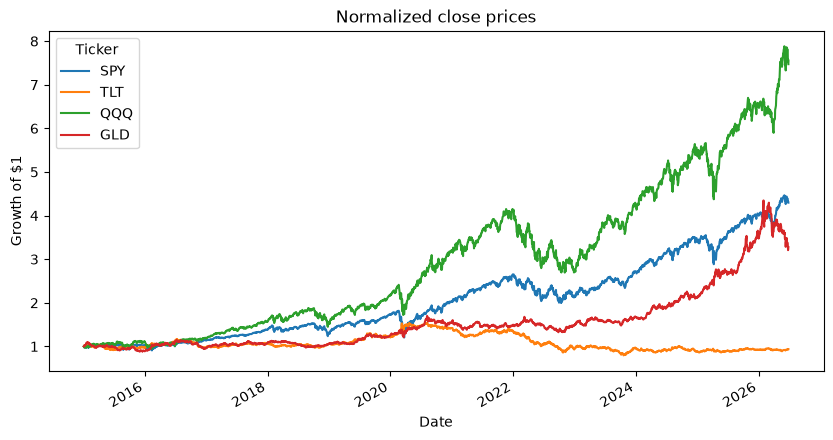

In [5]:
if isinstance(prices.columns, pd.MultiIndex):
    close_level = -1 if "Close" in prices.columns.get_level_values(-1) else 0
    close = prices.xs("Close", axis=1, level=close_level)
else:
    close = prices[["Close"]].rename(columns={"Close": tickers[0]})

normalized_close = close / close.iloc[0]
normalized_close.plot(figsize=(10, 5), title="Normalized close prices")
plt.ylabel("Growth of $1")
plt.show()

In [6]:
returns = close.pct_change()
features = pd.DataFrame(index=close.index)

# Recent returns and volatility for each asset.
for ticker in close.columns:
    features[f"{ticker}_ret_1d"] = returns[ticker]
    for window in [5, 20, 60]:
        features[f"{ticker}_ret_{window}d"] = close[ticker].pct_change(window)
        features[f"{ticker}_vol_{window}d"] = returns[ticker].rolling(window).std() * np.sqrt(252)

# Rolling correlations versus SPY.
for ticker in [ticker for ticker in close.columns if ticker != "SPY"]:
    for window in [20, 60]:
        features[f"SPY_{ticker}_corr_{window}d"] = returns["SPY"].rolling(window).corr(returns[ticker])

# Distance from the recent one-year high.
for ticker in close.columns:
    rolling_high = close[ticker].rolling(252, min_periods=60).max()
    features[f"{ticker}_drawdown_252d"] = close[ticker] / rolling_high - 1

# Bond-stock relationship.
features["SPY_TLT_return_spread_20d"] = close["SPY"].pct_change(20) - close["TLT"].pct_change(20)
features["SPY_TLT_return_spread_60d"] = close["SPY"].pct_change(60) - close["TLT"].pct_change(60)
features["SPY_TLT_corr_60d"] = returns["SPY"].rolling(60).corr(returns["TLT"])
features["TLT_momentum_60d"] = close["TLT"].pct_change(60)

# Gold momentum and gold strength relative to stocks.
features["GLD_momentum_20d"] = close["GLD"].pct_change(20)
features["GLD_momentum_60d"] = close["GLD"].pct_change(60)
features["GLD_vs_SPY_60d"] = close["GLD"].pct_change(60) - close["SPY"].pct_change(60)

# Market regime labels using only trailing information.
spy_ma_200 = close["SPY"].rolling(200).mean()
features["SPY_above_200d_avg"] = (close["SPY"] > spy_ma_200).where(spy_ma_200.notna())

trend_regime = pd.Series(pd.NA, index=close.index, dtype="object")
trend_regime[close["SPY"] > spy_ma_200] = "uptrend"
trend_regime[close["SPY"] <= spy_ma_200] = "downtrend"
features["trend_regime"] = trend_regime
features["trend_is_up"] = (trend_regime == "uptrend").astype(float).where(trend_regime.notna())

spy_vol_60d = features["SPY_vol_60d"]
vol_low_threshold = spy_vol_60d.rolling(252, min_periods=126).quantile(0.33)
vol_high_threshold = spy_vol_60d.rolling(252, min_periods=126).quantile(0.67)

vol_regime = pd.Series(pd.NA, index=close.index, dtype="object")
vol_regime[spy_vol_60d <= vol_low_threshold] = "low_vol"
vol_regime[(spy_vol_60d > vol_low_threshold) & (spy_vol_60d < vol_high_threshold)] = "mid_vol"
vol_regime[spy_vol_60d >= vol_high_threshold] = "high_vol"
features["vol_regime"] = vol_regime
features["vol_is_low"] = (vol_regime == "low_vol").astype(float).where(vol_regime.notna())
features["vol_is_mid"] = (vol_regime == "mid_vol").astype(float).where(vol_regime.notna())
features["vol_is_high"] = (vol_regime == "high_vol").astype(float).where(vol_regime.notna())

target = returns["SPY"].shift(-1).rename("spy_next_day_return")
dataset = pd.concat([features, target], axis=1).dropna()
dataset.head()

,SPY_ret_1d,SPY_ret_5d,SPY_vol_5d,SPY_ret_20d,SPY_vol_20d,SPY_ret_60d,SPY_vol_60d,TLT_ret_1d,TLT_ret_5d,TLT_vol_5d,...,GLD_momentum_60d,GLD_vs_SPY_60d,SPY_above_200d_avg,trend_regime,trend_is_up,vol_regime,vol_is_low,vol_is_mid,vol_is_high,spy_next_day_return
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-16,0.004546,0.009636,0.137710,0.040010,0.168281,-0.027849,0.219388,0.000324,0.013494,0.088764,...,0.078213,0.106062,False,downtrend,0.0,high_vol,0.0,0.0,1.0,0.000492
2015-10-19,0.000492,0.009180,0.137954,0.035173,0.167938,-0.017176,0.218401,-0.002744,0.003084,0.082926,...,0.063313,0.080489,False,downtrend,0.0,high_vol,0.0,0.0,1.0,-0.001279
2015-10-20,-0.001279,0.014282,0.123035,0.047444,0.159205,-0.012690,0.218100,-0.006149,-0.004781,0.094440,...,0.075052,0.087742,False,downtrend,0.0,high_vol,0.0,0.0,1.0,-0.006203
2015-10-21,-0.006203,0.012845,0.128831,0.042614,0.161549,-0.030720,0.216897,0.009932,-0.003615,0.102142,...,0.063893,0.094613,False,downtrend,0.0,high_vol,0.0,0.0,1.0,0.016894
2015-10-22,0.016894,0.014381,0.138542,0.064075,0.168130,-0.021079,0.219296,0.001693,0.002987,0.095609,...,0.061995,0.083074,True,uptrend,1.0,high_vol,0.0,0.0,1.0,0.010962


In [7]:
processed_path = PROCESSED_DIR / "starter_returns_dataset.csv"
dataset.to_csv(processed_path)
processed_path

WindowsPath('C:/Users/nqmin/Documents/Project/Predictions/data/processed/starter_returns_dataset.csv')